In [1]:
!ls

sample_data


In [2]:
from google.colab import files
uploaded = files.upload()


Saving StudentPerformanceFactors (1).csv to StudentPerformanceFactors (1).csv


***PROJECT INTRODUCTION***




This project analyzes different factors that influence students’ exam performance using data analytics. The dataset includes variables such as study hours, attendance, parental involvement, resources, and other personal and academic factors. The aim of the project is to understand how these factors affect students’ exam scores and identify important patterns in the data.

**IMPORTING LIBRARIES**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**DATASET LOADING**

In [6]:
df = pd.read_csv("StudentPerformanceFactors (1).csv")


**DATASET OVERVIEW**

*Dataset shape*


In [ ]:
df.shape

(6607, 20)

The data set contains 6607 rows and 20 columns.

*Finding Columns*

In [ ]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

*Columns Data Types*

In [ ]:
df.dtypes

,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


**DATASET STRUCTURE**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [ ]:
df.describe(include="object")

,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6529,6607,6607,6607,6517,6540,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,3925,4598,2638,5912,3223,3884,3814


**ROW OVERVIEW**

In [ ]:
df.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


**DATA PREPROCESSING**

*Finding null values*

In [ ]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [ ]:
#filling the null values using mode

df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0], inplace=True)
df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0], inplace=True)
df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0], inplace=True)

Missing values in categorical variables were handled using mode imputation, where missing values were replaced with the most frequent value in each column.

In [ ]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


*Finding Duplicates*

In [ ]:
df.duplicated().any()

np.False_

No duplicates were found.

**CREATING NEW COLUMN**

*1) Performance level*

In [ ]:

df['Performance_Level'] = pd.cut(df['Exam_Score'],
                                bins=[0,50,70,100],
                                labels=['Low','Medium','High'])

In [ ]:
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Performance_Level
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,Medium
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,Medium
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,High
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,High
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Medium,Public,Positive,2,No,High School,Near,Female,68,Medium
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,High,Public,Positive,2,No,High School,Near,Female,69,Medium
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68,Medium
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,Medium,Private,Positive,3,No,High School,Far,Female,68,Medium


A new column called Performance Level was created by categorizing exam scores into Low, Medium, and High groups to simplify analysis and visualization.


*2) Study Support*

In [ ]:
df['Study_Support'] = df['Hours_Studied'] + df['Tutoring_Sessions']
df[['Hours_Studied','Tutoring_Sessions','Study_Support']].head()

,Hours_Studied,Tutoring_Sessions,Study_Support
0,23,0,23
1,19,2,21
2,24,2,26
3,29,1,30
4,19,3,22


A new column called Study Support was created by combining Hours Studied and Tutoring Sessions to represent the total academic effort of a student

**EXPLORITORY DATA ANALYSIS**

In [ ]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Studu Efficiency,Performance_Level,Study_Support
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Positive,3,No,High School,Near,Male,67,2.913043,Medium,23
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Negative,4,No,College,Moderate,Female,61,3.210526,Medium,21
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Neutral,4,No,Postgraduate,Near,Male,74,3.083333,High,26
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Negative,4,No,High School,Moderate,Male,71,2.448276,High,30
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,Neutral,4,No,College,Near,Female,70,3.684211,Medium,22


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,3814
Female,2793


In [ ]:
df['School_Type'].value_counts()

,count
School_Type,
Public,4598
Private,2009


In [ ]:
df['Motivation_Level'].value_counts()

,count
Motivation_Level,
Medium,3351
Low,1937
High,1319


Frequency distribution was examined for categorical variables.

*Average score by gender*

In [ ]:
df.groupby('Gender')['Exam_Score'].mean()

,Exam_Score
Gender,
Female,67.244898
Male,67.228894


*Effect of internet access*

Students with internet access have slightly higher exam scores than those without internet access.

In [ ]:
df.groupby('Internet_Access')['Exam_Score'].mean()

,Exam_Score
Internet_Access,
No,66.535070
Yes,67.292895


*Family income impact*

Students from high-income families have slightly higher exam scores, but the difference between income groups is small.


In [ ]:
df.groupby('Family_Income')['Exam_Score'].mean()

,Exam_Score
Family_Income,
High,67.842396
Low,66.848428
Medium,67.334959


*Teacher Quality Impact*

Students taught by high-quality teachers have slightly higher exam scores, but the difference between groups is small.

In [ ]:
df.groupby('Teacher_Quality')['Exam_Score'].mean()

,Exam_Score
Teacher_Quality,
High,67.676939
Low,66.753425
Medium,67.100175


*Study Hours Ctegory*

No increase in Exam score as study hours increase

In [ ]:
df.groupby('Hours_Studied')['Exam_Score'].mean().head()

,Exam_Score
Hours_Studied,
1,71.000000
2,63.000000
3,61.333333
4,61.647059
5,62.857143


*Attendance Impact*

This means students with higher attendance tend to score higher in exams.

In [ ]:
df[['Attendance','Exam_Score']].corr()

,Attendance,Exam_Score
Attendance,1.000000,0.581072
Exam_Score,0.581072,1.000000


Top Factors correlation

Attendance, study support, and hours studied are the factors most related to exam scores, while other factors show only a weak relationship.



In [ ]:
df.corr(numeric_only=True)['Exam_Score'].sort_values(ascending=False)

,Exam_Score
Exam_Score,1.000000
Attendance,0.581072
Study_Support,0.469162
Hours_Studied,0.445455
Previous_Scores,0.175079
Tutoring_Sessions,0.156525
Physical_Activity,0.027824
Sleep_Hours,-0.017022
Studu Efficiency,-0.164321


*Performance level distribution*

Most students belongs to the medium performance group.

In [ ]:
df['Performance_Level'].value_counts()

,count
Performance_Level,
Medium,5524
High,1082
Low,0


*Distribution Analysis*

1.   Study Hour Distribution
2.   Sleep Hour Distribution
3.   Attendance Distribution



In [ ]:
df['Hours_Studied'].describe()

,Hours_Studied
count,6607.000000
mean,19.975329
std,5.990594
min,1.000000
25%,16.000000
50%,20.000000
75%,24.000000
max,44.000000


In [ ]:
df['Sleep_Hours'].describe()

,Sleep_Hours
count,6607.00000
mean,7.02906
std,1.46812
min,4.00000
25%,6.00000
50%,7.00000
75%,8.00000
max,10.00000


In [ ]:
df['Attendance'].describe()

,Attendance
count,6607.000000
mean,79.977448
std,11.547475
min,60.000000
25%,70.000000
50%,80.000000
75%,90.000000
max,100.000000


*Lifestyle Analysis*

In [ ]:
df.groupby('Physical_Activity')['Sleep_Hours'].mean()

,Sleep_Hours
Physical_Activity,
0,7.108696
1,6.990499
2,7.021512
3,7.055796
4,7.004444
5,6.988920
6,7.343750


*School Enviroment Analysis*

In [ ]:
df.groupby('School_Type')['Attendance'].mean()

,Attendance
School_Type,
Private,80.303136
Public,79.835146


*Resource Analysis*

Students with better access to resources mostly have internet access, while few students lack it.

In [ ]:
df.groupby('Access_to_Resources')['Internet_Access'].value_counts()

Access_to_Resources  Internet_Access
High                 Yes                1819
                     No                  156
Low                  Yes                1224
                     No                   89
Medium               Yes                3065
                     No                  254
Name: count, dtype: int64

 **VISUALIZATION**

            *STUDENT PERFORMANCE OVERVIEW*

**EXAMSCORE DISTRIBUTION**



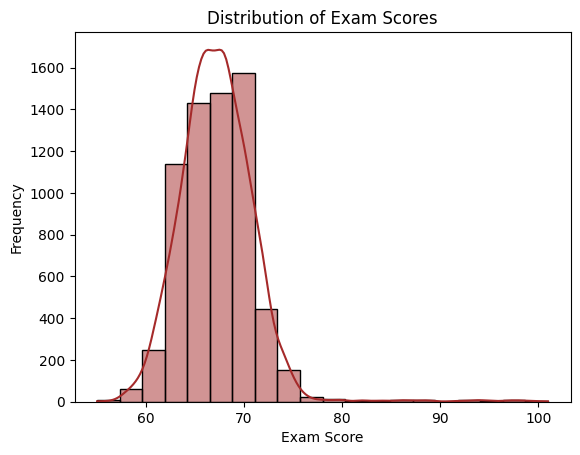

In [ ]:
sns.histplot(df['Exam_Score'], kde=True, bins=20, color='brown')
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()



*   The distribution of exam scores follows an approximately normal pattern.
*   Most students scored between 65 and 75,indicating a moderate and consistant academic performance.
*  Very few students scored extremely low or extremely high scores.



**PERFORMANCE LEVEL COUNTPLOT**

/tmp/ipython-input-3168103263.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Performance_Level', data=df, palette='pastel')


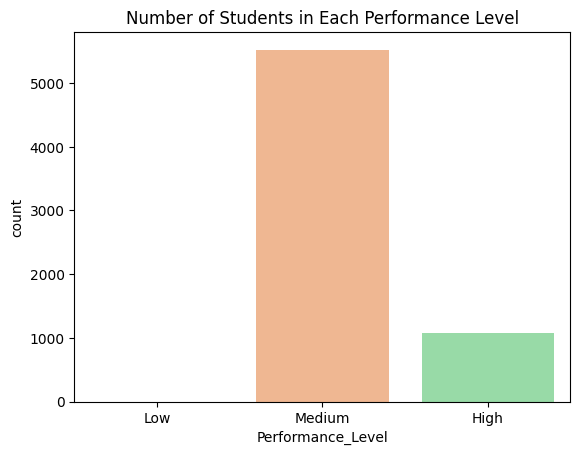

In [ ]:
sns.countplot(x='Performance_Level', data=df, palette='pastel')
plt.title("Number of Students in Each Performance Level")
plt.show()



*   Majority of the students fall under the medium performance category,which indicates that most students exhibit average academic achievement.
*   The number of high-performing students are low in numbe.
*   Overall academic performace is stable.But there is a scope to improve the number of high achiever.



**EXAM SCORE vs PREVIOUS SCORE**

<Axes: xlabel='Previous_Scores', ylabel='Exam_Score'>

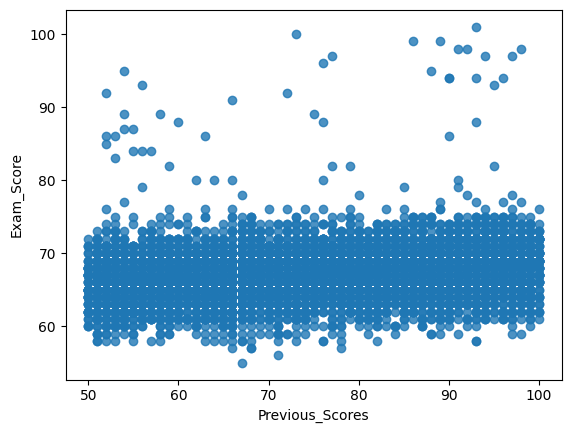

In [ ]:
sns.regplot(x='Previous_Scores', y='Exam_Score', data=df)

* The regression plot indicates a weak to moderate positive relationship between previous academic  scores and current exam performance.
* While students with higher previous scores tend to achieve better results,
exam performance is influenced and enviromental factors.

                 STUDENT CHARECTERISTICS

---



***PERFORMANCE LEVEL BASED ON LEARNING DISABILITY***

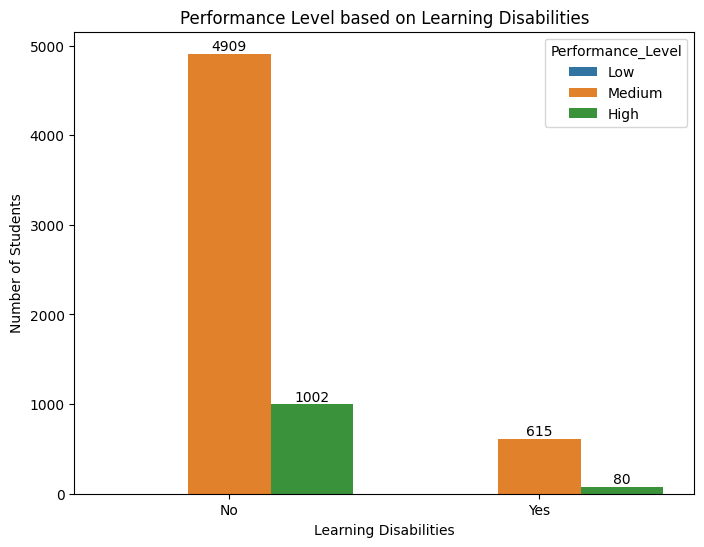

In [ ]:
plt.figure(figsize=(8,6))

ax = sns.countplot(
    x='Learning_Disabilities',
    hue='Performance_Level',
    data=df
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Performance Level based on Learning Disabilities")
plt.xlabel("Learning Disabilities")
plt.ylabel("Number of Students")

plt.show()

* The bar chart indicates thet students without learning disabilities constitute the majority of the dataset.
* Medium performance level is the most common category in both groups.
* However the proportion of high performing students is lower among students with learning disabilities.
* This suggests that learning disabilities may have a moderate impact on academic performance, particularly in achieving higher performance level.

---



***STUDENTS AT ACADEMIC RISK***

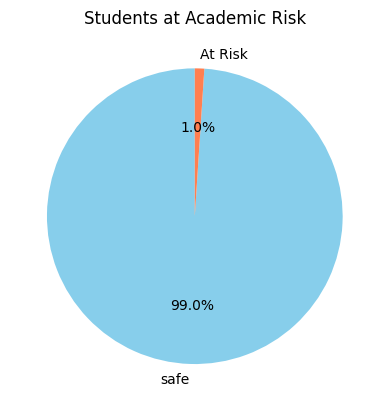

In [ ]:
df['Risk_Level']= df['Exam_Score'].apply(
    lambda x: "At Risk" if x < 60 else "safe"
)

counts = df['Risk_Level'].value_counts()
plt.figure()
plt.pie(counts,
        labels=counts.index,
        autopct=('%1.1f%%'),
        colors=['skyblue', 'coral'],
        startangle=90)
plt.title("Students at Academic Risk")
plt.ylabel("")
plt.show()

The analysis reveals that only 1% of students fall under the academic risk category, while 99% are performing at a safe level.
This indicates overall strong academic performance within the dataset though targeted support may be necessary for at_risk students.


                     FAMILY INFLUENCE

***PARENTAL EDUCATIONAL LEVEL vs PARENTAL INVOLVEMENT***

[Text(0, 0, '1710'), Text(0, 0, '981'), Text(0, 0, '671')]

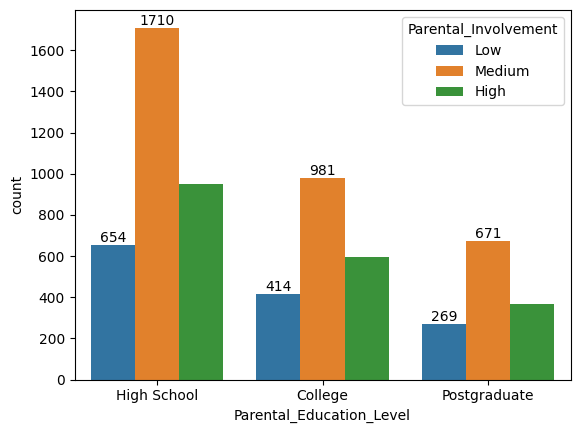

In [ ]:
ax = sns.countplot(x='Parental_Education_Level', hue='Parental_Involvement', data=df)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

* The analysis shows that medium parental involvement is the most common across all parental education levels.
* Parents with high school education forms the largest group in the dataset,displaying substantial involvement in thier childrens academics.
* Low parental involvement is the common category,suggesting that most parents,regardless of educational background ,maintain a least a moderate level of engagement in their child's education.


                         SCHOOL FACTORS

***SCHOOL TYPE vs TEACHER QUALITY***

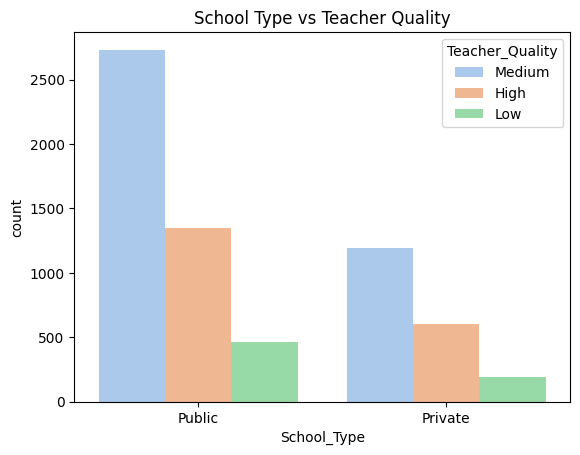

In [ ]:
plt.figure()
sns.countplot(x='School_Type', hue='Teacher_Quality', data=df, palette='pastel')
plt.title("School Type vs Teacher Quality")
plt.show()


* The analysis indicates that medium teacher quality is the most common category in both public and private schools.
* Public schools display higher overall counts across all quality levels, likely due to a large student population.
* High quality teachers are present in both school types, while low quality teachers represent the smallest proportion.
* Overall,teacher quality distribution appears consistent across school types, with no extreme imbalance.

***TEACHER QUALITY vs EXAM SCORE***

/tmp/ipython-input-3301546736.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Teacher_Quality', y='Exam_Score', data=df, palette='pastel')


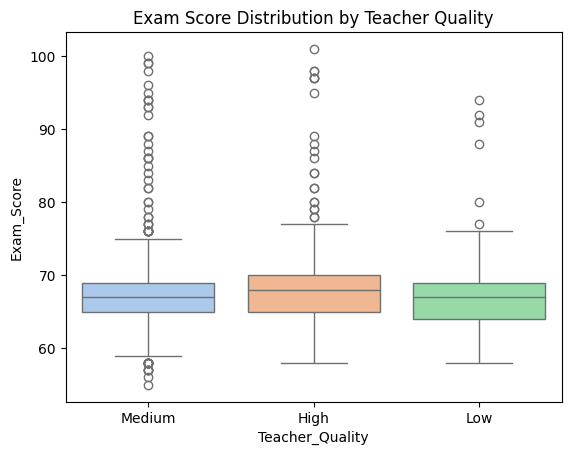

In [ ]:
plt.figure()
sns.boxplot(x='Teacher_Quality', y='Exam_Score', data=df, palette='pastel')
plt.title("Exam Score Distribution by Teacher Quality")
plt.show()

* The boxplot indicates a slight upward in median exam scores for students taught by high quality teachers.
* However ,the overall distribution and variability of scores remain similar across all teacher quality level.
* While teacher quality appears to have a positive influence on performance, the difference is moderate.

***ACCESS TO EDUCATIONAL RESOURCES***

In [ ]:
table = pd.crosstab(
    [df['Family_Income'], df['School_Type']],
    df['Access_to_Resources'],
    normalize='index'
) * 100
table  = table.round(1)
table

Access_to_Resources        High   Low  Medium
Family_Income School_Type                    
High          Private      28.7  19.6    51.7
              Public       30.6  18.4    51.0
Low           Private      33.4  19.8    46.8
              Public       30.1  20.0    49.9
Medium        Private      32.0  19.8    48.2
              Public       27.2  20.6    52.3

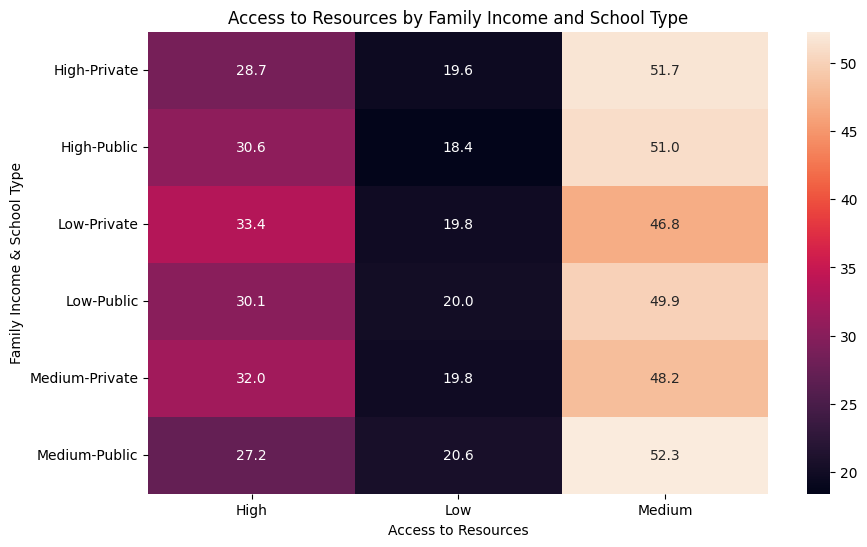

In [ ]:
table = pd.crosstab(
    [df['Family_Income'], df['School_Type']],
    df['Access_to_Resources'],
    normalize='index'
) * 100

plt.figure(figsize=(10,6))
sns.heatmap(table, annot=True, fmt=".1f")

plt.title("Access to Resources by Family Income and School Type")
plt.ylabel("Family Income & School Type")
plt.xlabel("Access to Resources")

plt.show()




*   The heatmap analysis reveals that most students,irrespective of family income and school type,fall under the medium level of access to resources.
*   low access remains the smallest proportion across all groups,indicating thet extreme deprivation is less common.
*   Differences between private and publuc schools are minimal, and income does not show a drastic impact on resource accessibility.
*   Overall, resources distribution appears moderately balanced rather than highly unequal across different socio-economic and institutional category.



                   STUDENT BEHAVIOUR AND EFFORT

***MOTIVATION LEVEL COUNT***

Text(0.5, 1.0, 'Motivation Level of Students')

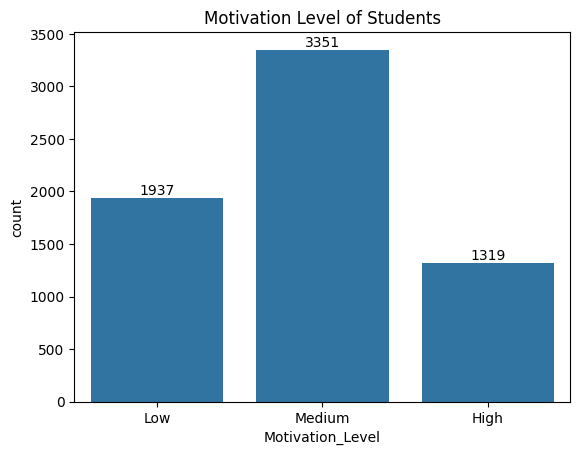

In [ ]:
ms=sns.countplot(x='Motivation_Level', data=df)
for container in ms.containers:
    ms.bar_label(container)
plt.title("Motivation Level of Students")

***MOTIVATION LEVEL vs AVERAGE EXAM SCORE***

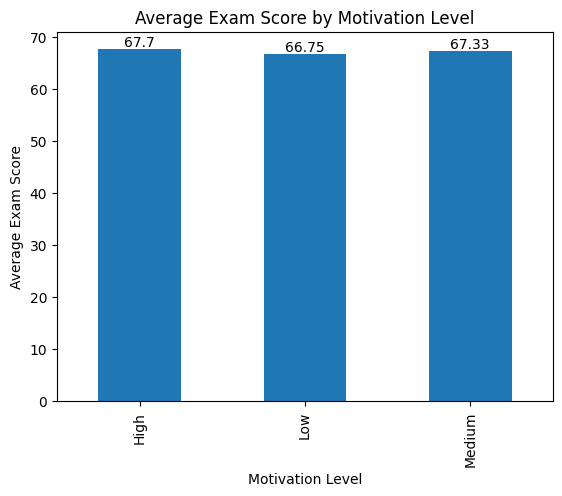

In [ ]:
plt.figure()
df.groupby('Motivation_Level')['Exam_Score'].mean().plot(kind='bar')
plt.title("Average Exam Score by Motivation Level")
plt.xlabel("Motivation Level")
plt.ylabel("Average Exam Score")
for i, value in enumerate(df.groupby('Motivation_Level')['Exam_Score'].mean()):
    plt.text(i, value + 0.5, round(value, 2), ha='center')
plt.show()




*   The bar chart shows that students with high motivation levels tend to achieve slightly higher average examscore compared to medium and low motivation groups.
*   However, the difference is not very large, indicating that while motivation plays a role in academic performance,other factors may also significantly influence exam outcomes.



***ATTENDANCE vs EXAM SCORE***

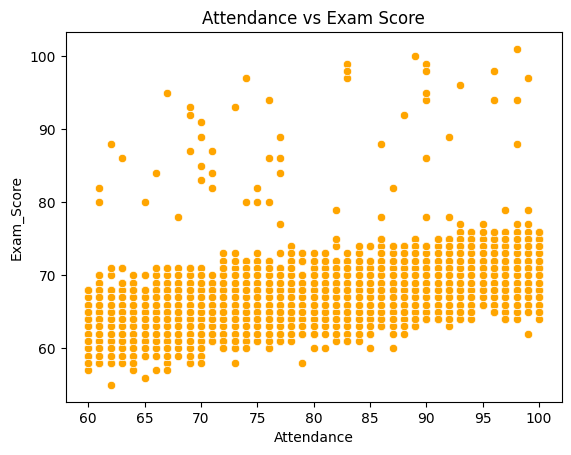

In [ ]:

plt.figure()
sns.scatterplot(x='Attendance', y='Exam_Score', data=df, color='orange')
plt.title("Attendance vs Exam Score")
plt.show()

* The plot reveals that there is a  positive relationship between attendence and examscore.
* Students with high attendence tend to have better academic performance.
* How ever the relationship is not perfectle linear,as several students with high attendence still scores moderately.


***HOURS STUDIED vs EXAMSCORE***

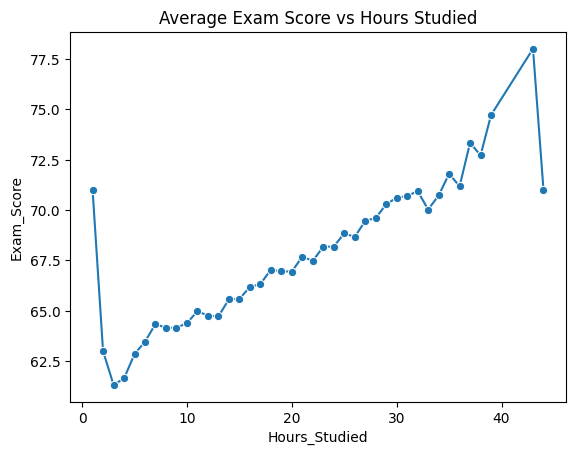

In [ ]:
mean_scores = df.groupby('Hours_Studied')['Exam_Score'].mean().reset_index()
sns.lineplot(x='Hours_Studied', y='Exam_Score', data=mean_scores, marker='o')
plt.title("Average Exam Score vs Hours Studied")
plt.show()




*   It shows a positive relationship between hour studied and examscore.
*   Students who spend more time in studying tend to achieve high scores.
*   However, some variations exist,suggesting that other factors also contribute to academic performance.



             LIFESTYLE FACTORS

***PHYSICAL ACTIVITY vs EXTRACURRICULAR ACTIVITY***

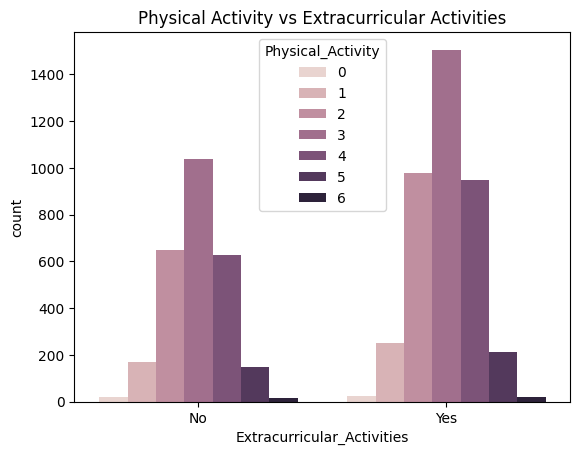

In [ ]:
sns.countplot(x='Extracurricular_Activities', hue='Physical_Activity', data=df)
plt.title("Physical Activity vs Extracurricular Activities")
plt.show()

*  The analysis indicates that students who participate in extracurricular activities tend to exhibit higher level of physical activity compared to those who do not.
*   Moderately activity levels(2 and 3) are the most common across both groups,while extremely high or low levels are rare.
*   over all the graphs suggests a positive relationship between extracurricular involvement and physical activity,implying that participation in school activities may promote a more active lifestyle among students.



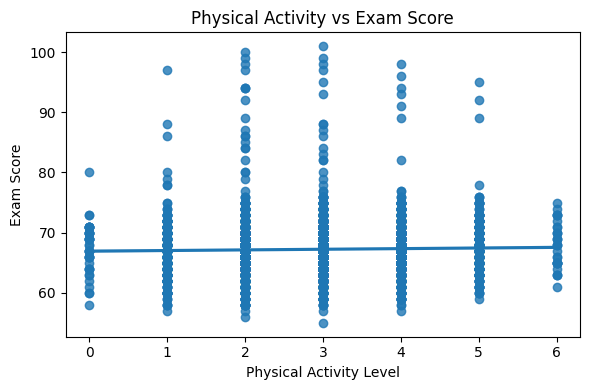

In [7]:
plt.figure(figsize=(6,4))
sns.regplot(
    x='Physical_Activity',
    y='Exam_Score',
    data=df
)

plt.title("Physical Activity vs Exam Score")
plt.xlabel("Physical Activity Level")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

* The plot indicates that students with moderate levels of physical activity tend to achieve slightly higher and more stable exam scores.
* Extremely low or high activity levels do not show significant academic advantages.
* Overall, physical activity demonstrates a weak but supportive relationship with exam performance rather than a strong direct effect.

**SLEEP HOUR vs HOURS STUDIED vs EXAM SCORE**

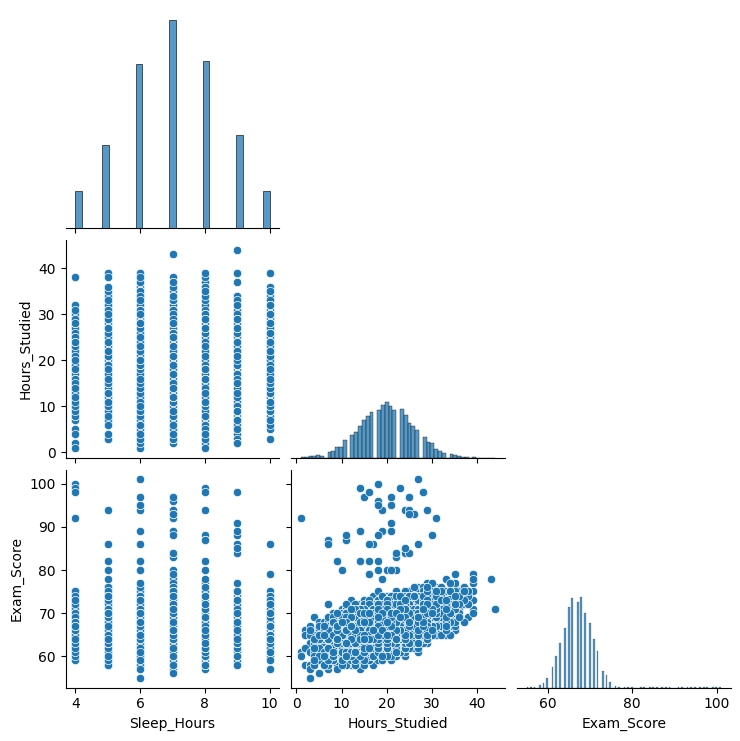

In [ ]:
cols = ['Sleep_Hours', 'Hours_Studied', 'Exam_Score']

sns.pairplot(df[cols], corner=True)
plt.show()

1.SLEEP HOUR vs HOURS STUDIED
  * The points are spread randomly
  * Students who slept more don't necessarily study more or less.

That means sleep anstudy hour are mostly independent .

2. HOURS STUDIES AND EXAM SCORE
   * It is the most important insight.
   * As hours studied increase exam score also increase.
   * in the graph we can see that points forming an upward slope.

This means as study hours increase the exam score also increase.

3. SLEEP HOUR AND EXAM SCORE
    * Here also the points are spread randomly.
    * No clear upward or downward trend.

Sleep alone does'nt strongly determine marks.


This pairplot illustrates the relationships among sleep hours, study hours, and exam scores. The analysis shows that study hours have the strongest direct influence on exam performance, while sleep hours play a supportive role by contributing to better study habits rather than directly determining exam outcomes.


                   FINAL STATISTICAL INSIGHT

***CORRELATION BETWEEN VARIABLES***


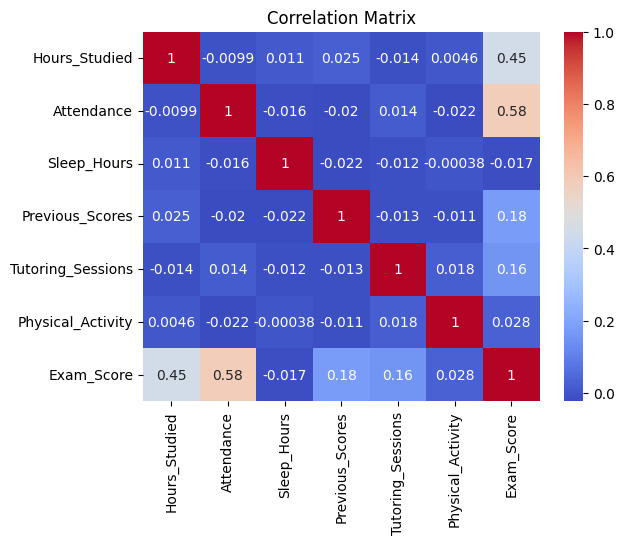

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()



*   The correlation analysis reveals that attendance (0.58) has the strongest positive relationship with exam scores,followed by Hours studied(0.45).
*   Other variables such as previous scores, tutoring sessions, sleep hour, and physical activity show a weak or negligible relationships with academic performance.
*   This indicates that consistent attendance and dedicated study time are the most significant factors influencing student success.



*Student Performance*

Majority of students fall under the medium performance category, indicating average academic achievement.The number of high-performing students is comparatively low.Overall academic performance is stable but there is scope to improve the number of high achievers.

*Parental Involvement*

Medium parental involvement is the most common across all parental education levels.Parents with high school education form the largest group in the dataset.Very few parents show low involvement, suggesting that most parents maintain at least moderate engagement in their children's education.

*Teacher Quality*

Medium teacher quality appears most frequently in both public and private schools.Public schools show higher counts mainly due to larger student population.High-quality teachers exist in both systems, while low-quality teachers are fewer.Overall distribution of teacher quality is fairly balanced.

*Attendance and Performance*

There is a positive relationship between attendance and exam score.Students with higher attendance tend to perform better.However, the relationship is not perfectly linear, indicating other influencing factors.

*Motivation Level*

Students with high motivation show slightly higher exam scores.
The difference is small, suggesting multiple factors affect performance.

*Learning Disabilities*

Students without learning disabilities form the majority of the dataset.
Medium performance level is common in both groups.
High performance is less frequent among students with learning disabilities, indicating some impact.

*Academic Risk*

Only 1% of students fall under academic risk, while 99% perform at a safe level.
This suggests overall strong academic stability.

Resource Accessibility

Most students fall under medium access to resources.
Low access is relatively rare.
Income and school type show only minor differences.

*Correlation Findings*

Attendance (0.58) has the strongest relationship with exam score.
Hours studied (0.45) is the second strongest factor.
Other variables show weak relationships.

***SUMMARY***

This project analyzed various factors affecting student academic performance, including attendance, motivation, parental involvement, teacher quality, learning disabilities, and access to resources. The findings reveal that most students demonstrate moderate academic performance, indicating overall stability in the dataset.

Attendance and study hours emerged as the most influential factors affecting exam scores, while other variables such as sleep, tutoring, and physical activity showed relatively weaker relationships. Teacher quality, parental involvement, and motivation also play supportive roles but do not create large performance differences.

Additionally, the analysis shows that the majority of students have moderate access to resources and study support. Only a very small percentage of students fall under academic risk, suggesting that the overall academic environment is fairly balanced and supportive.

***FUTURE SUGGESTIONS***

- Conduct remedial classes for low performers.
- Introduce advanced programs for high achievers.
- Promote consistent attendance.
- Organize parent workshops and awareness programs.
- Encourage regular parent-teacher communication.
- Focus on engaging parents with lower educational background.
- Provide professional development & trainin.g
- Share best teaching practices between teachers.
- Recognize high-quality teachers to motivate them.
- Introduce mentorship & goal-setting programs.
- Promote effective study habits and time management.
- Provide study support resources where needed.
- Encourage balanced extracurricular involvement (sports, arts, clubs).
- Organize school events to promote active lifestyle.
- Conduct periodic assessments to track progress.
- Use data-driven strategies for teaching improvements.
- Focus on predictive metrics like attendance & previous scores.
- Create positive and supportive learning environment.
- Reduce barriers affecting attendance and participation.